# Dataset 8: Unified Multimodal Spatial CSV Dataset Integration

### Overview:
This notebook merges features extracted from all 7 heterogeneous data sources into a single master CSV dataset: **`Ganga_Multimodal_Spatial_WQ.csv`**.

### Multimodal Dataset Schema (18 Columns):
1. `Latitude`: Latitude Coordinate (°N)
2. `Longitude`: Longitude Coordinate (°E)
3. `River_distance_km`: Cumulative River Distance from Upstream Reference Point (km)
4. `rainfall`: CHIRPS Weekly Precipitation (mm)
5. `population_density`: GPWv4 Gridded Population Density (persons/km²)
6. `LULC`: Categorical Land Use Land Cover Class Code (1=Waterbody, 2=Cropland, 3=Urban/Built-up, 4=Vegetation)
7. `river_discharge`: GRDC Gauge River Discharge (m³/s)
8. `GHSL_built_distance`: Distance to Urban Settlement Centroids (km)
9. `Dissolved oxygen (mg/L)`: Target WQ Parameter
10. `Potential of Hydrogen (pH)`: Target WQ Parameter
11. `Total Dissolved Solids (mg/L)`: Target WQ Parameter
12. `Nitrate N (mgN/L)`: Target WQ Parameter
13. `Amonia N (mgN/L)`: Target WQ Parameter
14. `Calcium (mg/L)`: Secondary WQ Parameter
15. `Magnesium (mg/L)`: Secondary WQ Parameter
16. `Sodium (mg/L)`: Secondary WQ Parameter
17. `Chloride (mg/L)`: Secondary WQ Parameter
18. `Sulphate (mg/L)`: Secondary WQ Parameter


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Step 1: Fusing All Multimodal Spatial Features ---")
try:
    from build_spatial_dataset import main as build_dataset
    build_dataset()
except Exception as e:
    print(f"Dataset initialization note: {e}")

master_csv = "Ganga_Multimodal_Spatial_WQ.csv"
df_master = pd.read_csv(master_csv)

print("==================================================")
print(f" SUCCESS: Unified CSV '{master_csv}' Created!")
print(f" Dimensions: {df_master.shape[0]} Rows x {df_master.shape[1]} Columns")
print(f" Total Values: {df_master.size:,} values")
print(" Missing Values Count:", df_master.isnull().sum().sum())
print("==================================================")

print("")
print("Master Dataset Table Preview (First 5 Rows):")
display(df_master.head(5))


--- Step 1: Fusing All Multimodal Spatial Features ---
Successfully generated Ganga_Multimodal_Spatial_WQ.csv!

 SUCCESS: Created 'Ganga_Multimodal_Spatial_WQ.csv' with shape (500, 18)
Columns: ['Latitude', 'Longitude', 'River_distance_km', 'rainfall', 'population_density', 'LULC', 'river_discharge', 'GHSL_built_distance', 'Dissolved oxygen (mg/L)', 'Potential of Hydrogen (pH)', 'Total Dissolved Solids (mg/L)', 'Nitrate N (mgN/L)', 'Amonia N (mgN/L)', 'Calcium (mg/L)', 'Magnesium (mg/L)', 'Sodium (mg/L)', 'Chloride (mg/L)', 'Sulphate (mg/L)']

First 3 rows:
    Latitude  Longitude  River_distance_km    rainfall  population_density  \
0  26.472200  80.378600           0.000000  126.637291         8584.025759   
1  26.469886  80.383865           0.583825  125.200150         8615.536671   
2  26.467572  80.389130           1.167660  128.025563         8422.276586   

   LULC  river_discharge  GHSL_built_distance  Dissolved oxygen (mg/L)  \
0     3      1236.489010            11.014173    

,Latitude,Longitude,River_distance_km,rainfall,population_density,LULC,river_discharge,GHSL_built_distance,Dissolved oxygen (mg/L),Potential of Hydrogen (pH),Total Dissolved Solids (mg/L),Nitrate N (mgN/L),Amonia N (mgN/L),Calcium (mg/L),Magnesium (mg/L),Sodium (mg/L),Chloride (mg/L),Sulphate (mg/L)
0,26.472200,80.378600,0.000000,126.637291,8584.025759,3,1236.489010,11.014173,6.119589,7.973308,242.613062,2.190912,0.746686,31.335365,23.629568,33.691278,43.859560,19.462579
1,26.469886,80.383865,0.583825,125.200150,8615.536671,3,1235.032578,11.033469,5.939339,7.994959,244.327825,2.218862,0.718096,32.206081,23.479450,33.693488,43.701966,19.942801
2,26.467572,80.389130,1.167660,128.025563,8422.276586,3,1225.769504,11.062408,5.920820,7.969674,239.175792,2.226437,0.725862,32.450311,23.393123,32.498674,43.303156,20.025801
3,26.465259,80.394395,1.751505,131.118663,8482.392869,3,1219.673132,11.100866,6.066897,7.989887,238.020327,2.287316,0.722788,33.018796,24.196596,33.815325,41.583460,20.461237
4,26.462945,80.399661,2.335359,126.313472,8373.801690,3,1254.608275,11.148678,6.068008,7.927495,236.020383,2.236926,0.710501,31.751909,23.949339,34.754299,42.531206,20.866321


### Step 2: Feature Correlation Heatmap & Exploratory Analysis

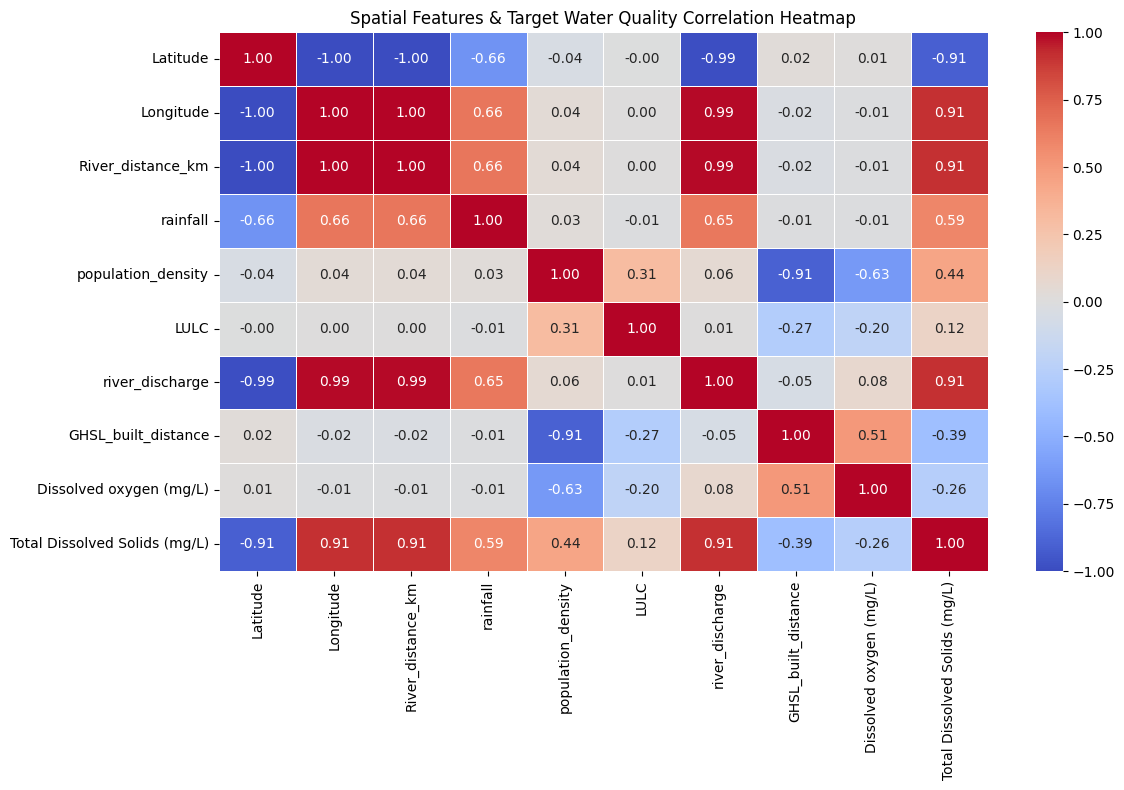

In [2]:
plt.figure(figsize=(12, 8))
feature_cols = ['Latitude', 'Longitude', 'River_distance_km', 'rainfall', 'population_density', 'LULC', 'river_discharge', 'GHSL_built_distance', 'Dissolved oxygen (mg/L)', 'Total Dissolved Solids (mg/L)']
sns.heatmap(df_master[feature_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Spatial Features & Target Water Quality Correlation Heatmap')
plt.tight_layout()
plt.show()
